<a href="https://colab.research.google.com/github/xiaofei-builds/self-driving-rover/blob/main/notebooks/train_pilotnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Sat Aug  1 16:37:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip -q -o /content/drive/MyDrive/xiaofei-builds/dataset.zip -d /content/
!ls /content/dataset | head
!wc -l /content/dataset/labels.csv

data
labels.csv
12580 /content/dataset/labels.csv


In [3]:
import csv, numpy as np
from datetime import datetime

N, STRIDE, GAP_S = 4, 4, 0.5
need = (N-1)*STRIDE                     # 12 frames of history required
LAB  = "/content/dataset/labels.csv"

rows=[]
with open(LAB) as f:
    for r in csv.DictReader(f):
        t = datetime.fromisoformat(r["timestamp"]).timestamp()
        rows.append((t, r["image"], float(r["steering"])))
rows.sort(key=lambda x: x[0])
images = [r[1] for r in rows]
steer  = np.array([r[2] for r in rows], dtype=np.float32)
ts     = [r[0] for r in rows]

runs=[]; s=0
for i in range(1,len(rows)):
    if ts[i]-ts[i-1] > GAP_S:
        runs.append((s,i)); s=i
runs.append((s,len(rows)))

rng=np.random.default_rng(42)
val_runs=set(); acc=0; tot=len(rows)
for ri in rng.permutation(len(runs)):
    a,b=runs[ri]
    if acc < 0.2*tot:
        val_runs.add(int(ri)); acc += (b-a)

def build(run_ids):
    seqs=[]
    for ri in run_ids:
        a,b=runs[ri]
        for i in range(a+need,b):
            seqs.append([i-3*STRIDE, i-2*STRIDE, i-1*STRIDE, i])
    return np.array(seqs,dtype=np.int32)

train_ids=[ri for ri in range(len(runs)) if ri not in val_runs]
val_ids  =[ri for ri in range(len(runs)) if ri in val_runs]
seq_tr=build(train_ids); seq_va=build(val_ids)
print("frames",len(rows),"runs",len(runs),"val_runs",len(val_runs))
print("train seqs",len(seq_tr),"val seqs",len(seq_va))

frames 12579 runs 48 val_runs 23
train seqs 8250 val seqs 3786


In [4]:
import cv2
H,W = 120,160
frames = np.zeros((len(images),H,W,3), dtype=np.uint8)
for k,name in enumerate(images):
    img = cv2.imread("/content/dataset/data/"+name)   # BGR
    frames[k] = img[:, :, ::-1]                        # -> RGB (deploy contract)
print("frames", frames.shape, "%.2f GB"%(frames.nbytes/1e9))

frames (12579, 120, 160, 3) 0.72 GB


In [5]:
import tensorflow as tf, gc
frames_const = tf.constant(frames)      # uint8 ~0.72GB
del frames; gc.collect()                # drop the numpy duplicate

def make_stack(seq_idx):
    f = tf.gather(frames_const, seq_idx)
    f = tf.transpose(f,[1,2,0,3])
    f = tf.reshape(f,[H,W,N*3])
    return tf.cast(f,tf.float32)/255.0

def gen_ds(seqs, training):
    y  = (steer[seqs[:,3]]/30.0).astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((seqs, y))
    if training:
        ds = ds.shuffle(len(seqs), reshuffle_each_iteration=True)  # shuffle TINY indices
    ds = ds.map(lambda s,l:(make_stack(s),l), num_parallel_calls=4)
    if training:
        def aug(x,l):
            x = tf.image.random_brightness(x,0.2)
            x = tf.image.random_contrast(x,0.8,1.2)
            x = tf.clip_by_value(x,0.,1.)
            do = tf.random.uniform([])<0.5
            x = tf.cond(do, lambda: tf.image.flip_left_right(x), lambda: x)
            l = tf.cond(do, lambda: -l, lambda: l)
            return x,l
        ds = ds.map(aug, num_parallel_calls=4)
    return ds.batch(64).prefetch(2)

train_ds = gen_ds(seq_tr, True)
val_ds   = gen_ds(seq_va, False)
print("one batch:", next(iter(train_ds))[0].shape)

one batch: (64, 120, 160, 12)


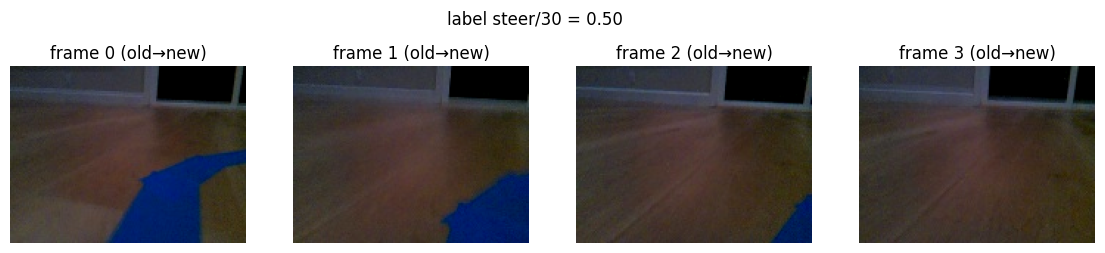

In [6]:
import matplotlib.pyplot as plt
xb,yb = next(iter(train_ds))
x0 = xb[0].numpy()
fig,ax = plt.subplots(1,4,figsize=(14,3))
for j in range(4):
    ax[j].imshow(x0[:,:,j*3:j*3+3]); ax[j].set_title(f"frame {j} (old→new)"); ax[j].axis('off')
plt.suptitle(f"label steer/30 = {yb[0].numpy():.2f}")
plt.show()

In [8]:
import os
ZIP = "/content/drive/MyDrive/xiaofei-builds/dataset.zip"
print("zip found:", os.path.exists(ZIP))
!rm -rf /content/dataset
!unzip -q -o "{ZIP}" -d /content
print("contents:", os.listdir("/content/dataset"))
print("image count:", len(os.listdir("/content/dataset/data")))

zip found: True
contents: ['labels.csv', 'data']
image count: 11779


(11779, 5)
   index                   timestamp           image  steering  throttle
0      0  2026-07-26T21:16:43.606880  img_000000.jpg         0        10
1      1  2026-07-26T21:16:43.638335  img_000001.jpg         0        10
2      2  2026-07-26T21:16:43.705097  img_000002.jpg         0        10

steering: -30 to 30


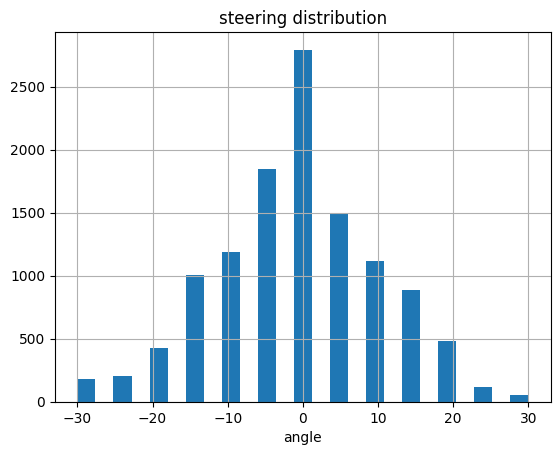

In [9]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("/content/dataset/labels.csv")
print(df.shape)
print(df.head(3))
print("\nsteering:", df.steering.min(), "to", df.steering.max())
df.steering.hist(bins=25); plt.title("steering distribution"); plt.xlabel("angle"); plt.show()

In [10]:
import numpy as np, cv2, os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

IMG_DIR = "/content/dataset/data"
N = len(df)
X = np.zeros((N, 120, 160, 3), dtype=np.float32)
for i, fn in enumerate(tqdm(df.image.values)):
    img = cv2.imread(os.path.join(IMG_DIR, fn))   # BGR, 120x160
    X[i] = img[:, :, ::-1] / 255.0                # BGR->RGB, scale 0..1
y = (df.steering.values.astype(np.float32)) / 30.0  # scale -1..1

Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", Xtr.shape, "  val:", Xval.shape)
print("pixel range:", X.min(), "to", X.max(), " | steering range:", y.min(), "to", y.max())

100%|██████████| 11779/11779 [00:10<00:00, 1132.77it/s]


train: (9423, 120, 160, 3)   val: (2356, 120, 160, 3)
pixel range: 0.0 to 1.0  | steering range: -1.0 to 1.0


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(120, 160, 12)),
    layers.Conv2D(24, 5, strides=2, activation='relu'),
    layers.Conv2D(32, 5, strides=2, activation='relu'),
    layers.Conv2D(64, 5, strides=2, activation='relu'),
    layers.Conv2D(64, 3, strides=2, activation='relu'),
    layers.Conv2D(64, 3, strides=1, activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(50, activation='relu'),
    layers.Dense(1)                      # linear output = steering
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 58, 78, 24)     │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 37, 32)     │        19,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 17, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,977 (1.04 MB)

 Trainable params: 271,977 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
cb = tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')
hist = model.fit(train_ds, validation_data=val_ds, epochs=60, callbacks=[cb])

Epoch 1/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - loss: 0.0878 - mae: 0.2022 - val_loss: 0.0686 - val_mae: 0.1649
Epoch 2/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - loss: 0.0561 - mae: 0.1485 - val_loss: 0.0669 - val_mae: 0.1513
Epoch 3/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - loss: 0.0468 - mae: 0.1326 - val_loss: 0.0582 - val_mae: 0.1430
Epoch 4/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - loss: 0.0381 - mae: 0.1241 - val_loss: 0.0634 - val_mae: 0.1516
Epoch 5/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - loss: 0.0486 - mae: 0.1374 - val_loss: 0.0527 - val_mae: 0.1330
Epoch 6/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - loss: 0.0330 - mae: 0.1179 - val_loss: 0.0505 - val_mae: 0.1273
Epoch 7/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - loss: 0.0326 - mae: 0.1151 - val_loss: 0.0516 - val_mae: 0.1298
Epoch 8/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - loss: 0.0295 - mae: 0.1105 - val_loss: 0.0475 - val_mae: 0.1233
Epoch 9/60
129/129 ━━━━━━━━━━━━━━

In [10]:
import numpy as np
xb, yb = next(iter(val_ds))
pred = model.predict(xb, verbose=0)[:,0]
true = yb.numpy()
order = np.argsort(-np.abs(true))
print(" true    pred")
for i in order[:10]:
    print(f"{true[i]*30:+6.1f}°  {pred[i]*30:+6.1f}°")


 true    pred
 -30.0°   -14.3°
 -30.0°   -23.3°
 -30.0°   -24.7°
 -30.0°   -24.7°
 -30.0°   -25.6°
 -30.0°   -23.9°
 -30.0°   -23.9°
 -30.0°   -16.3°
 -30.0°   -16.5°
 -30.0°   -17.2°


In [11]:
conv = tf.lite.TFLiteConverter.from_keras_model(model)
tfl  = conv.convert()
open("/content/pilot_stateful.tflite","wb").write(tfl)

# verify tflite == keras to the decimal
xb,yb = next(iter(val_ds)); x1 = xb[:1].numpy()
k = model.predict(x1, verbose=0)[0,0]
itp = tf.lite.Interpreter(model_content=tfl); itp.allocate_tensors()
ind=itp.get_input_details()[0]; outd=itp.get_output_details()[0]
itp.set_tensor(ind['index'], x1); itp.invoke()
t = itp.get_tensor(outd['index'])[0,0]
print("tflite input shape", ind['shape'])
print(f"keras {k:.5f}  tflite {t:.5f}  diff {abs(k-t):.2e}")

import shutil, os
os.makedirs("/content/drive/MyDrive/xiaofei-builds/model", exist_ok=True)
shutil.copy("/content/pilot_stateful.tflite","/content/drive/MyDrive/xiaofei-builds/model/pilot_stateful.tflite")
model.save("/content/drive/MyDrive/xiaofei-builds/model/pilot_stateful.keras")
print("saved to Drive/model/pilot_stateful.*")


Saved artifact at '/tmp/tmpt2yxtly4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 160, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132595682849808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682852112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682852688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682852304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682851152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682850384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682850000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682850768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682852496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132595682848848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1325956828505

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


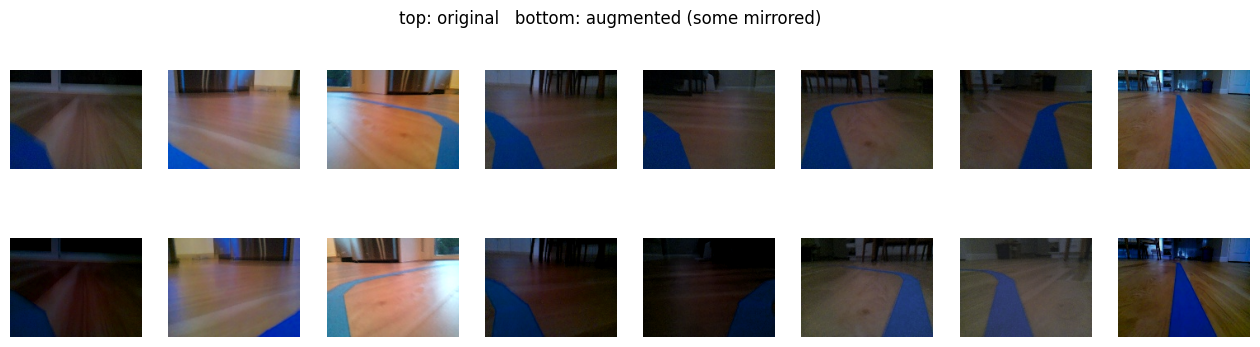

steering sign flip: ['-0.17->+0.17', '-0.33->+0.33', '+0.67->-0.67', '-0.17->+0.17']


In [12]:
import tensorflow as tf, matplotlib.pyplot as plt

def augment(img, label):
    img = tf.image.random_brightness(img, 0.2)      # exposure
    img = tf.image.random_contrast(img, 0.8, 1.2)   # contrast
    img = tf.image.random_saturation(img, 0.7, 1.3) # color intensity
    img = tf.image.random_hue(img, 0.03)            # color temperature
    img = tf.clip_by_value(img, 0.0, 1.0)
    # NEW: coordinated horizontal flip + steering sign flip
    do_flip = tf.random.uniform([]) < 0.5
    img   = tf.cond(do_flip, lambda: tf.image.flip_left_right(img), lambda: img)
    label = tf.cond(do_flip, lambda: -label, lambda: label)
    return img, label

s = Xtr[:8]
fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    ax[0,i].imshow(s[i]); ax[0,i].axis('off')
    ax[1,i].imshow(augment(tf.constant(s[i]), tf.constant(0.0))[0]); ax[1,i].axis('off')
plt.suptitle('top: original   bottom: augmented (some mirrored)'); plt.show()
plt.show()

# sanity check the label math: mirroring must negate steering
print("steering sign flip:", [f"{ytr[i]:+.2f}->{-ytr[i]:+.2f}" for i in range(4)])

In [13]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (tf.data.Dataset.from_tensor_slices((Xtr, ytr))
            .shuffle(len(Xtr)).map(augment, num_parallel_calls=AUTOTUNE)
            .batch(64).prefetch(AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((Xval, yval))
          .batch(64).prefetch(AUTOTUNE))          # NOT augmented

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                      restore_best_weights=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=60, callbacks=[es])

Epoch 1/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 109ms/step - loss: 0.0956 - mae: 0.2195 - val_loss: 0.0677 - val_mae: 0.1766
Epoch 2/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 0.0681 - mae: 0.1791 - val_loss: 0.0595 - val_mae: 0.1715
Epoch 3/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0602 - mae: 0.1677 - val_loss: 0.0570 - val_mae: 0.1579
Epoch 4/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0548 - mae: 0.1608 - val_loss: 0.0459 - val_mae: 0.1477
Epoch 5/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0519 - mae: 0.1562 - val_loss: 0.0492 - val_mae: 0.1536
Epoch 6/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.0501 - mae: 0.1524 - val_loss: 0.0472 - val_mae: 0.1477
Epoch 7/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 0.0489 - mae: 0.1508 - val_loss: 0.0451 - val_mae: 0.1428
Epoch 8/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.0478 - mae: 0.1486 - val_loss: 0.0469 - val_mae: 0.1449
Epoch 9/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE loss'); plt.title('learning curve'); plt.show()

best = min(history.history['val_mae'])
print("best val MAE (normalized):", round(best, 4))
print("average steering error in DEGREES:", round(best * 30, 2))


NameError: name 'history' is not defined

In [17]:
import numpy as np
idx = np.random.choice(len(Xval), 10, replace=False)
pred = (model.predict(Xval[idx], verbose=0) * 30).flatten()
true = yval[idx] * 30
print(" predicted | you drove")
for p, t in zip(pred, true):
    print(f"   {p:+6.1f}  |  {t:+6.1f}")

 predicted | you drove
    +14.5  |   +15.0
     -4.6  |    -5.0
    -15.5  |   -25.0
    +15.2  |   +15.0
    -10.9  |   -10.0
     -2.6  |    -5.0
     +1.9  |    +0.0
     -7.3  |   +10.0
     +6.2  |    +5.0
     -2.5  |    +0.0


In [18]:
import numpy as np

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("/content/pilot.tflite", "wb") as f:
    f.write(tflite_model)
print("TF-Lite size:", round(len(tflite_model)/1024, 1), "KB")

Saved artifact at '/tmp/tmp6et7vyhb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 120, 160, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139414658437712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658438480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658439440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658440016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658439824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658439248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658440208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658437904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658440400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139414658441360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13941465844155

In [1]:
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp = interp.get_input_details()[0]
out = interp.get_output_details()[0]

x = Xval[0:1].astype(np.float32)
interp.set_tensor(inp['index'], x); interp.invoke()
tflite_pred = interp.get_tensor(out['index'])[0,0] * 30
keras_pred  = model.predict(x, verbose=0)[0,0] * 30
print(f"tflite: {tflite_pred:+.2f}   keras: {keras_pred:+.2f}")
print("input the Pi must feed:", inp['shape'], inp['dtype'])

NameError: name 'tf' is not defined

In [20]:
import shutil, os
DST = "/content/drive/MyDrive/xiaofei-builds/model"
os.makedirs(DST, exist_ok=True)
shutil.copy("/content/pilot.tflite", f"{DST}/pilot.tflite")   # for the Pi
model.save(f"{DST}/pilot.keras")                              # full backup for retraining
print(os.listdir(DST))

['pilot.tflite', 'pilot.keras']
